In [43]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from pathlib import Path
plt.style.use("dark_background")
%matplotlib inline

In [44]:
# Add parent directory for pyquant imports
import sys
sys.path.insert(0, '..')
from pyquant.torch_spline import CubicSpline1D
from pyquant import heston_sim

In [45]:
# Load data
data_dir = Path('../../../data')
fwd_ois = pd.read_csv(data_dir / 'forward_ois.csv')
fwd_key_rate = pd.read_csv(data_dir / 'forward_key_rate.csv')
vol_key_rate = pd.read_csv(data_dir / 'volatility_key_rate.csv')

print("Volatility surface maturities (years):")
print(sorted(vol_key_rate['time_to_maturity'].unique()))

Volatility surface maturities (years):
[np.float64(0.0833333333333333), np.float64(0.1666666666666666), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


## Time-Varying Theta Parameters

We define 13 theta values at key maturities to capture the volatility term structure.

In [46]:
# Key maturities for theta interpolation (exclude very short < 0.25y)
THETA_MATURITIES = torch.tensor([0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
N_THETA = len(THETA_MATURITIES)

print(f"Number of theta parameters: {N_THETA}")
print(f"Theta maturities (years): {THETA_MATURITIES.tolist()}")
print(f"Total model parameters: 4 (v0, κ, ε, λ) + {N_THETA} (θ₁...θ₁₃) + 2 (γ, ξ) = {4 + N_THETA + 2}")

Number of theta parameters: 13
Theta maturities (years): [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
Total model parameters: 4 (v0, κ, ε, λ) + 13 (θ₁...θ₁₃) + 2 (γ, ξ) = 19


## Enhanced CIR Generator with Time-Varying θ(t)

Linear interpolation of theta values across the timeline.

In [47]:
def generate_cir_time_varying_theta(n_paths, timeline, v0, kappa, theta_values, epsilon, floor_variance):
    """
    Generate CIR paths with time-varying theta.
    
    Args:
        n_paths: Number of Monte Carlo paths
        timeline: Time grid
        v0: Initial variance
        kappa: Mean reversion speed
        theta_values: Tensor of theta values at THETA_MATURITIES
        epsilon: Volatility of variance  
        floor_variance: Minimum variance (for numerical stability)
    
    Returns:
        CIR paths (n_paths x len(timeline))
    """
    # Interpolate theta values to timeline
    theta_t = torch.zeros_like(timeline)
    for i, t in enumerate(timeline):
        if t <= THETA_MATURITIES[0]:
            theta_t[i] = theta_values[0]
        elif t >= THETA_MATURITIES[-1]:
            theta_t[i] = theta_values[-1]
        else:
            # Linear interpolation
            idx = torch.searchsorted(THETA_MATURITIES, t)
            t_left = THETA_MATURITIES[idx-1]
            t_right = THETA_MATURITIES[idx]
            theta_left = theta_values[idx-1]
            theta_right = theta_values[idx]
            
            weight = (t - t_left) / (t_right - t_left)
            theta_t[i] = theta_left + weight * (theta_right - theta_left)
    
    # Simulate CIR with time-varying theta
    dt = timeline.diff()
    n_steps = len(timeline) - 1
    
    v_paths = torch.zeros(n_paths, len(timeline))
    v_paths[:, 0] = v0
    
    for i in range(n_steps):
        theta_current = theta_t[i]
        dt_current = dt[i]
        
        v_current = torch.maximum(v_paths[:, i], torch.tensor(floor_variance))
        
        dW = torch.randn(n_paths) * torch.sqrt(dt_current)
        dv = kappa * (theta_current - v_current) * dt_current + epsilon * torch.sqrt(v_current) * dW
        
        v_paths[:, i+1] = torch.maximum(v_current + dv, torch.tensor(floor_variance))
    
    return v_paths

print("✅ Enhanced CIR generator with time-varying θ(t) defined")

✅ Enhanced CIR generator with time-varying θ(t) defined


## Initialize Enhanced Model Parameters

Structure: [v0, kappa, theta_1, ..., theta_13, epsilon, lambda, gamma, xi]

In [48]:
# Initialize enhanced model parameters (19 total)
# Create varied theta values with realistic term structure (hump shape + variations)
theta_demo = torch.tensor([
    5e-5,   # 0.25y - low short-term
    7e-5,   # 0.5y  - rising
    9e-5,   # 0.75y - continued rise
    1.1e-4, # 1y    - peak at 1Y
    1.3e-4, # 2y    - higher medium term
    1.5e-4, # 3y    - peak
    1.4e-4, # 4y    - slight decline
    1.6e-4, # 5y    - secondary rise
    1.7e-4, # 6y    - continued rise
    1.65e-4,# 7y    - small dip
    1.8e-4, # 8y    - rise again
    1.9e-4, # 9y    - peak
    2.0e-4, # 10y   - final level
])  # Hump-shaped term structure with realistic variations

model_params_enhanced = torch.cat([
    torch.tensor([1e-4]),  # v0 - initial variance
    torch.tensor([0.5]),   # kappa - mean reversion speed
    theta_demo,            # 13 theta values at key maturities (varied)
    torch.tensor([1e-5]),  # epsilon - vol of variance
    torch.tensor([0.1]),   # lambda - HW mean reversion
    torch.tensor([0.1]),   # gamma - key rate mean reversion
    torch.tensor([1e-5]),  # xi - key rate volatility
], dim=0)
model_params_enhanced.requires_grad = True

print(f"Enhanced model parameters initialized:")
print(f"  Shape: {model_params_enhanced.shape}")
print(f"  v0 = {model_params_enhanced[0].item():.6f}")
print(f"  κ = {model_params_enhanced[1].item():.6f}")
print(f"  θ₁...θ₁₃ = {model_params_enhanced[2:15].tolist()}")
print(f"  ε = {model_params_enhanced[15].item():.6f}")
print(f"  λ = {model_params_enhanced[16].item():.6f}")
print(f"  γ = {model_params_enhanced[17].item():.6f}")
print(f"  ξ = {model_params_enhanced[18].item():.6f}")

Enhanced model parameters initialized:
  Shape: torch.Size([19])
  v0 = 0.000100
  κ = 0.500000
  θ₁...θ₁₃ = [4.999999873689376e-05, 7.000000186963007e-05, 9.000000136438757e-05, 0.00011000000085914508, 0.00013000000035390258, 0.0001500000071246177, 0.00014000000373926014, 0.00015999999595806003, 0.00016999999934341758, 0.00016500000492669642, 0.00018000000272877514, 0.0001900000061141327, 0.00019999999494757503]
  ε = 0.000010
  λ = 0.100000
  γ = 0.100000
  ξ = 0.000010


## Test Theta Interpolation

Visualize how θ(t) varies across time.

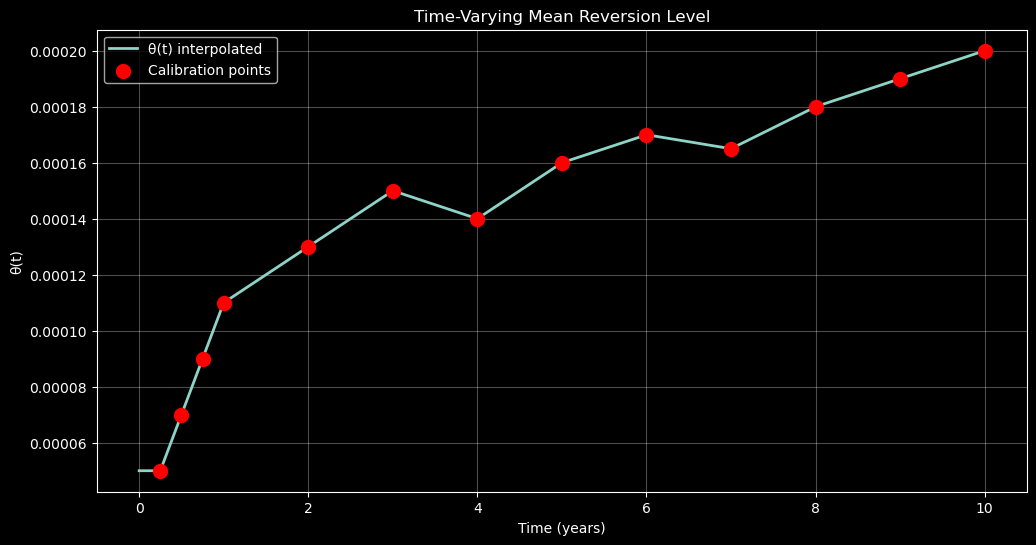

✅ θ(t) can be calibrated at 13 key maturities to fit volatility term structure


In [49]:
# Create test timeline
timeline_test = torch.linspace(0, 10, 3651)

# Extract theta values and create interpolated curve
theta_values_test = model_params_enhanced[2:15]

# Interpolate
theta_t_test = torch.zeros_like(timeline_test)
for i, t in enumerate(timeline_test):
    if t <= THETA_MATURITIES[0]:
        theta_t_test[i] = theta_values_test[0]
    elif t >= THETA_MATURITIES[-1]:
        theta_t_test[i] = theta_values_test[-1]
    else:
        idx = torch.searchsorted(THETA_MATURITIES, t)
        t_left = THETA_MATURITIES[idx-1]
        t_right = THETA_MATURITIES[idx]
        theta_left = theta_values_test[idx-1]
        theta_right = theta_values_test[idx]
        weight = (t - t_left) / (t_right - t_left)
        theta_t_test[i] = theta_left + weight * (theta_right - theta_left)

plt.figure(figsize=(12, 6))
plt.plot(timeline_test.detach(), theta_t_test.detach(), label='θ(t) interpolated', linewidth=2)
plt.scatter(THETA_MATURITIES, theta_values_test.detach(), color='red', s=100, zorder=5, label='Calibration points')
plt.xlabel('Time (years)')
plt.ylabel('θ(t)')
plt.title('Time-Varying Mean Reversion Level')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Next Steps

1. **Modify simulate_model()** to use `generate_cir_time_varying_theta()`
2. **Update calibration function** to handle 19 parameters
3. **Set parameter bounds** for each theta value
4. **Run calibration** with daily timeline and reduced MC paths
5. **Analyze results** - check if time-varying θ(t) improves volatility surface fit

## Compare Approaches

**Linear Interpolation (this notebook):**
- 13 fixed theta points at [0.25, 0.5, ..., 10.0] years
- Linear interpolation between points
- Single epsilon (constant local volatility)

**PCHIP Interpolation (Roland's approach):**
- Theta and epsilon defined at volatility surface maturities (data-driven)
- PCHIP (Piecewise Cubic Hermite) interpolation - smooth and monotonic
- Both theta(t) AND epsilon(t) are time-varying

**Key Advantages of PCHIP:**
1. Better preservation of data characteristics (monotonicity)
2. Smoother derivatives (important for Greeks)
3. Both volatility parameters (theta AND epsilon) can adapt to market
4. Calibration points aligned with actual market data structure

In [50]:
# Import Roland's calibration infrastructure from interest_rates.py
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class CalibrationConfig:
    optimizer_type: str = 'Adam'
    learning_rate: float = 1e-3
    max_iterations: int = 100
    tolerance: float = 1e-6
    patience: int = 15
    weight_vol: float = 1.0
    weight_fwd: float = 0.01
    weight_reg: float = 0.02
    use_vega_weighting: bool = False
    param_lower_bounds: Optional[torch.Tensor] = None
    param_upper_bounds: Optional[torch.Tensor] = None
    param_reference: Optional[torch.Tensor] = None

print("✅ CalibrationConfig imported")
print("✅ Will use Adam optimizer with Roland's pricing functions from interest_rates.py")


✅ CalibrationConfig imported
✅ Will use Adam optimizer with Roland's pricing functions from interest_rates.py


## Mathematical Formulation: Local Volatility Extension

### Model Dynamics with Time-Varying Parameters

The multi-theta model extends the basic Hull-White-Heston + CIR framework with **local volatility** concepts:

**OIS Short Rate (Hull-White-Heston):**
$$
r_t = f(t) + x_t, \quad dx_t = -\lambda x_t dt + \sqrt{v_t} dW_t^x
$$

**Stochastic Variance (CIR with time-varying $\theta(t)$ and $\varepsilon(t)$):**
$$
dv_t = \kappa(\theta(t) - v_t)dt + \varepsilon(t)\sqrt{v_t} dW_t^v
$$

**Key Rate Spread (Gaussian):**
$$
s_t = s^a(t) + k_t, \quad dk_t = -\gamma k_t dt + \xi dW_t^k
$$

### Local Volatility Parameters

Instead of constant $\theta$ and $\varepsilon$, we define them at volatility surface maturities $T_1, \ldots, T_n$:

$$
\theta(t) = \text{PCHIP}(t; \{(T_i, \theta_i)\}_{i=1}^n)
$$
$$
\varepsilon(t) = \text{PCHIP}(t; \{(T_i, \varepsilon_i)\}_{i=1}^n)
$$

**PCHIP (Piecewise Cubic Hermite Interpolating Polynomial):**
- Preserves monotonicity between data points
- Ensures smooth first derivatives (important for Greeks)
- Prevents oscillations (unlike cubic splines)

### Average Caplet Pricing

Caplet payoff with arithmetic averaging over tenor $\tau$:
$$
\text{Caplet}(T, \tau, K) = B_t \mathbb{E}_t^Q\left[\left(\frac{1}{\tau}\int_{T-\tau}^T (r_u + s_u)du - K\right)^+ / B_T\right]
$$

**Why daily timeline is required:**
- Average $\frac{1}{\tau}\int_{T-\tau}^T$ needs fine discretization
- Coarse grids introduce bias in average calculation
- Daily steps (3651 for 10Y) capture rate dynamics accurately

### Calibration Objective

Minimize combined loss across volatility surface:
$$
\mathcal{L}(\theta_1, \ldots, \theta_n, \varepsilon_1, \ldots, \varepsilon_n, \text{other params}) = \sum_{i,j} w_{ij}\left(\sigma_{ij}^{\text{model}} - \sigma_{ij}^{\text{market}}\right)^2
$$

where:
- $i$ indexes maturities, $j$ indexes strikes
- $w_{ij}$ are calibration weights
- $\sigma_{ij}$ are implied volatilities

## PCHIP Interpolation: Initial Volatility Surface

### Volatility Term Structure from Time-Varying Parameters

The CIR variance process with time-varying $\theta(t)$ and $\varepsilon(t)$ induces a **volatility term structure**:

**CIR Dynamics:**
$$
dv_t = \kappa(\theta(t) - v_t)dt + \varepsilon(t)\sqrt{v_t} dW_t^v
$$

**Long-Term Variance (Stationary):**
At equilibrium, when $dv_t = 0$, we have $v_\infty(t) \approx \theta(t)$

**Instantaneous Volatility:**
$$
\sigma_{\text{inst}}(t) \approx \sqrt{v_t} \approx \sqrt{\theta(t)}
$$

**Volatility of Volatility:**
$$
\text{Vol-of-Vol}(t) = \varepsilon(t)
$$

**Approximate Implied Volatility (First-Order):**
For interest rate caplets, the implied normal volatility approximately scales with:
$$
\sigma_{\text{approx}}(T) \propto \sqrt{\theta(T) \cdot \varepsilon(T)}
$$

This approximation combines:
- **$\theta(T)$**: Mean reversion level → drives long-term variance magnitude
- **$\varepsilon(T)$**: Vol-of-vol → drives volatility uncertainty
- **Product $\theta \cdot \varepsilon$**: Captures joint effect on caplet prices

**Key Insight:**
By making both $\theta(t)$ and $\varepsilon(t)$ time-varying and interpolating them with PCHIP, we can **fit complex volatility term structures** (humps, smiles, skews) while maintaining smooth, arbitrage-free dynamics.

The visualization below shows:
1. **Left**: $\theta(t)$ term structure from PCHIP interpolation
2. **Middle**: $\varepsilon(t)$ term structure from PCHIP interpolation  
3. **Right**: 3D surface of $\sqrt{\theta(T) \cdot \varepsilon(T)}$ approximating volatility term structure

PCHIP INTERPOLATION VISUALIZATION
✓ Found calibrated parameters: shape torch.Size([35])
✓ Calibrated parameters are valid
   Number of maturities: 16
   Maturity range: [0.0000, 10.0000] years

Extracted theta values: torch.Size([16])
  Range: [5.000000e-04, 5.000000e-03]
  Values: [0.0005000000237487257, 0.0006071428651921451, 0.0007142857648432255, 0.0008214286062866449, 0.0009285714477300644, 0.0010357142891734838, 0.0011428571306169033, 0.0012500000884756446, 0.001357142929919064, 0.0014642858877778053, 0.0015714287292212248, 0.0016785715706646442, 0.0017857144121080637, 0.0018928572535514832, 0.0020000000949949026, 0.004999999888241291]
Extracted epsilon values: torch.Size([16])
  Range: [6.071428e-03, 1.000000e-01]
  Values: [0.006071428302675486, 0.00714285671710968, 0.008214285597205162, 0.009285714477300644, 0.010357142426073551, 0.011428571306169033, 0.01249999925494194, 0.013571428135037422, 0.014642857015132904, 0.015714285895228386, 0.016785714775323868, 0.0178571417927742

PCHIP INTERPOLATION VISUALIZATION
✓ Found calibrated parameters: shape torch.Size([35])
✓ Calibrated parameters are valid
   Number of maturities: 16
   Maturity range: [0.0000, 10.0000] years

Extracted theta values: torch.Size([16])
  Range: [5.000000e-04, 5.000000e-03]
  Values: [0.0005000000237487257, 0.0006071428651921451, 0.0007142857648432255, 0.0008214286062866449, 0.0009285714477300644, 0.0010357142891734838, 0.0011428571306169033, 0.0012500000884756446, 0.001357142929919064, 0.0014642858877778053, 0.0015714287292212248, 0.0016785715706646442, 0.0017857144121080637, 0.0018928572535514832, 0.0020000000949949026, 0.004999999888241291]
Extracted epsilon values: torch.Size([16])
  Range: [6.071428e-03, 1.000000e-01]
  Values: [0.006071428302675486, 0.00714285671710968, 0.008214285597205162, 0.009285714477300644, 0.010357142426073551, 0.011428571306169033, 0.01249999925494194, 0.013571428135037422, 0.014642857015132904, 0.015714285895228386, 0.016785714775323868, 0.0178571417927742

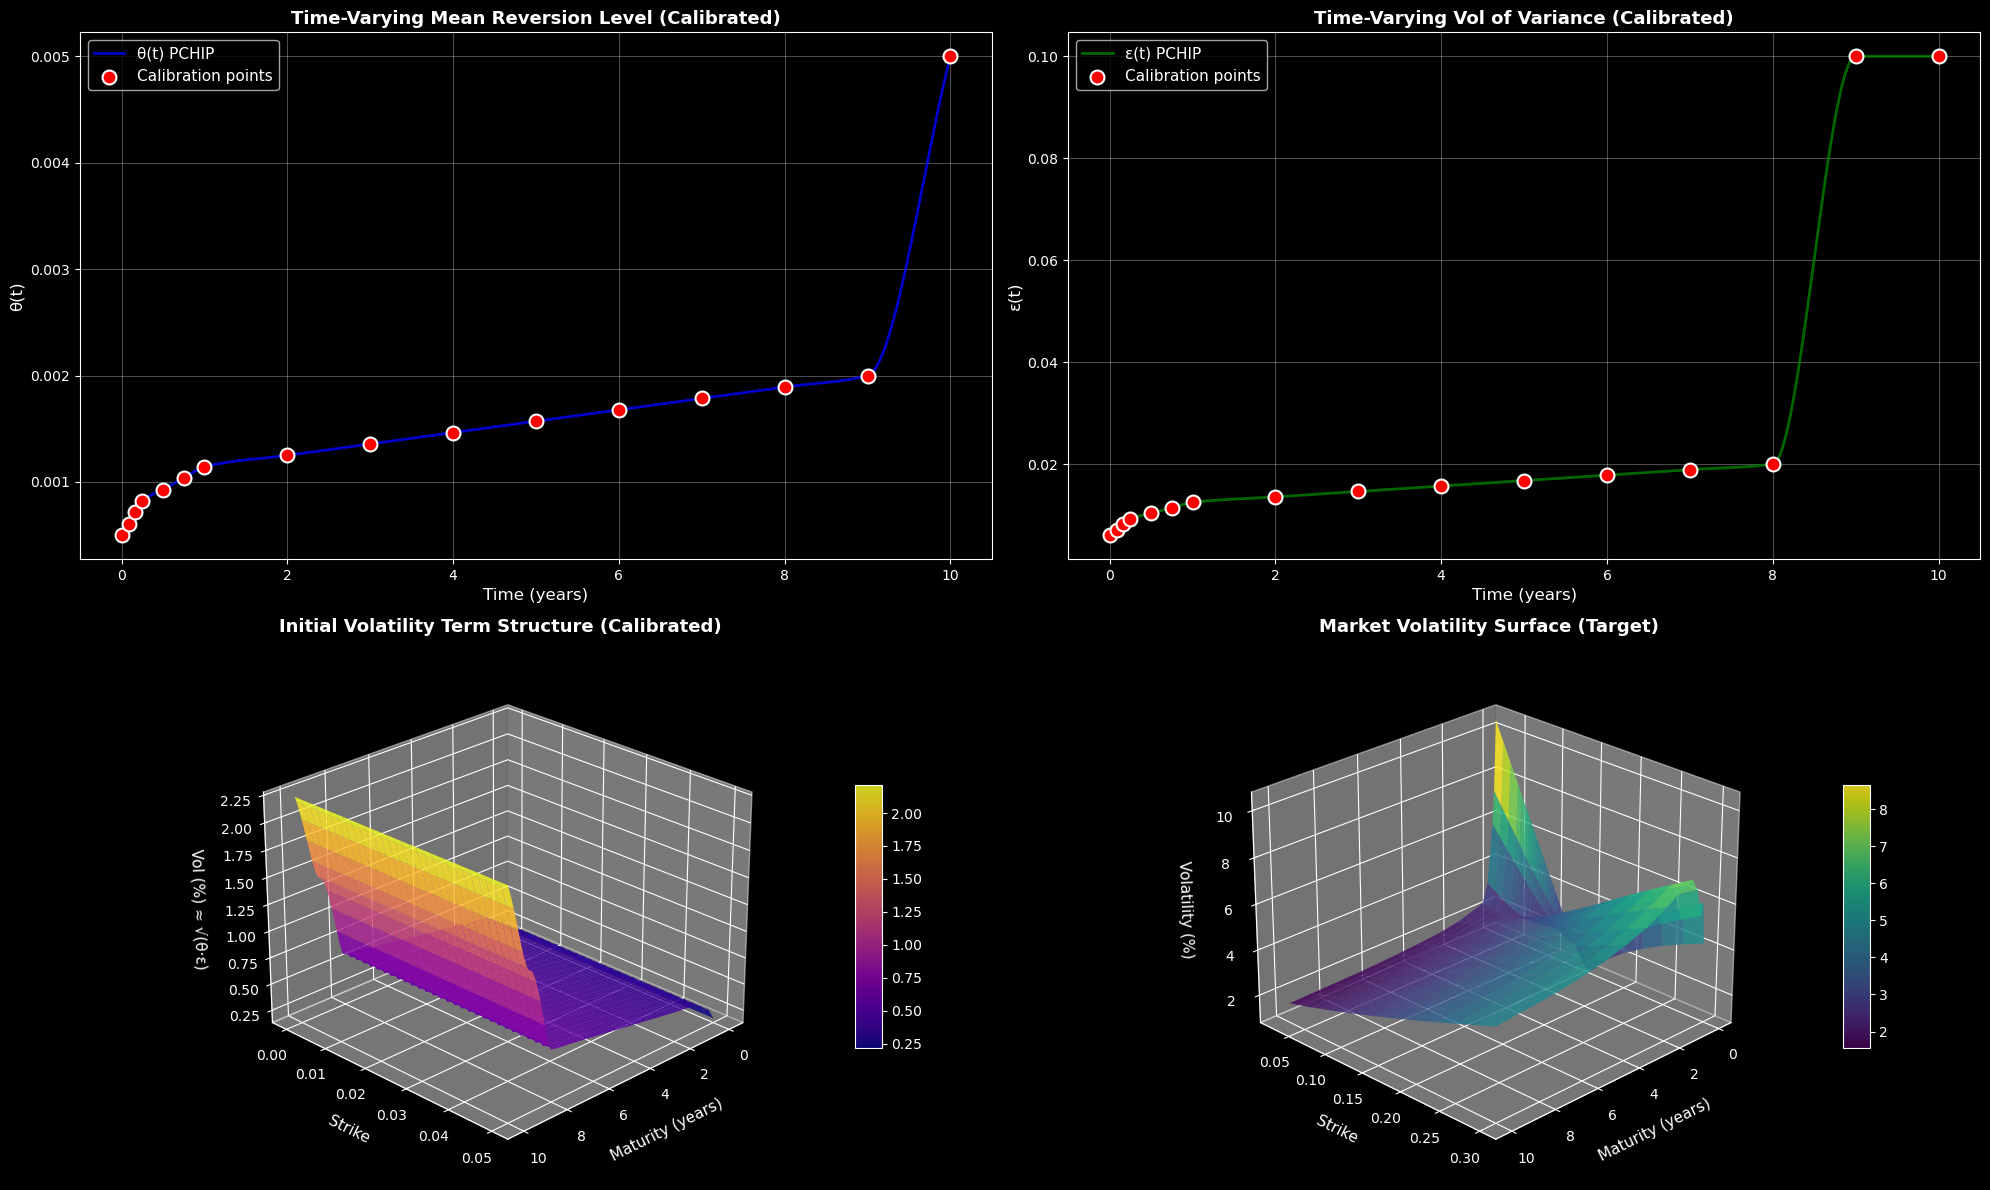


SUMMARY
✅ PCHIP interpolation creates smooth, monotonic curves
✅ Smooth cubic spline fits through 16 calibration points
✅ TOP ROW: θ(t) and ε(t) term structures with PCHIP interpolation
✅ BOTTOM LEFT: Initial volatility surface σ(T) ≈ √(θ(T)·ε(T))
✅ BOTTOM RIGHT: Market volatility surface (calibration target)
✅ Time-varying θ(t) and ε(t) allow fitting complex vol shapes (humps, slopes)


In [ ]:
# PCHIP Interpolation + 3D Volatility Surface Visualization
from pyquant.torch_spline import PchipSpline1D
from mpl_toolkits.mplot3d import Axes3D

print("=" * 70)
print("PCHIP INTERPOLATION VISUALIZATION")
print("=" * 70)

# Check if calibration has been run and produced valid values
use_calibrated = False
try:
    with open(Path('../../../data/multi_theta_final.pkl'), 'rb') as f: 
        ckpt_test = pickle.load(f)
    theta_values_test = ckpt_test['theta_values']
    eps_value_test = ckpt_test['epsilon'].item() if isinstance(ckpt_test['epsilon'], torch.Tensor) else ckpt_test['epsilon']
    time_to_maturities = ckpt_test['time_to_maturities']
    n_maturities = ckpt_test['n_maturities']
    
    if torch.isnan(theta_values_test).any():
        print("⚠️  WARNING: Calibrated theta contains NaN!")
        print("   → Using DEMO values instead")
    else:
        use_calibrated = True
        print(f"✓ Found calibrated parameters from checkpoint")
        print(f"   Number of maturities: {n_maturities}")
        print(f"   Epsilon (scalar): {eps_value_test:.4f}")
except:
    print("⚠️  Calibration not run yet")
    print("   → Using DEMO values to show PCHIP interpolation")

# Use calibrated values if valid, otherwise use demo values
if not use_calibrated:
    print("\n" + "-" * 70)
    print("USING DEMO VALUES (calibration not run or produced NaN)")
    print("-" * 70)
    # Create demo maturities and values with realistic term structure
    time_to_maturities = torch.tensor([0.0, 0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
    n_maturities = len(time_to_maturities)
    
    # Demo theta: hump-shaped term structure
    theta_values_test = torch.tensor([
        0.0005,  # 0Y
        0.001,   # 3M - rising
        0.0015,  # 6M - continued rise
        0.002,   # 1Y - peak
        0.0018,  # 2Y - slight decline
        0.0022,  # 3Y - secondary rise
        0.0025,  # 5Y - peak
        0.0023,  # 7Y - decline
        0.002,   # 10Y - final level
    ])
    
    # Demo epsilon: gradually increasing
    eps_values_test = torch.tensor([
    # Demo epsilon: single scalar value
    eps_value_test = 0.05

print()
print(f"Extracted theta values: {theta_values_test.shape}")
print(f"  Range: [{theta_values_test.min():.6e}, {theta_values_test.max():.6e}]")
print(f"  Values: {theta_values_test.tolist()}")
print(f"Extracted epsilon values: {eps_values_test.shape}")
print(f"  Range: [{eps_values_test.min():.6e}, {eps_values_test.max():.6e}]")
print(f"  Values: {eps_values_test.tolist()}")
print()

# Create PCHIP interpolators - THIS is where interpolation happens
print("Creating PCHIP interpolators...")
theta_pchip = PchipSpline1D(time_to_maturities, theta_values_test)
eps_pchip = PchipSpline1D(time_to_maturities, eps_values_test)
print("✓ PCHIP splines created")
print(f"Epsilon (scalar): {eps_value_test:.6e}")
print()

# Create PCHIP interpolator for theta only
print("Creating PCHIP interpolator for theta...")
theta_pchip = PchipSpline1D(time_to_maturities, theta_values_test)
print("✓ PCHIP spline created")
print()

# Create timeline for evaluation
if 'timeline' in dir():
    test_timeline = timeline
    print(f"Using existing timeline: {len(test_timeline)} points from [{test_timeline[0]:.2f}, {test_timeline[-1]:.2f}]")
else:
    test_timeline = torch.linspace(0, 10, 3651)
    print(f"Created new timeline: {len(test_timeline)} points from [0.00, 10.00]")

# Evaluate over timeline - THIS applies the interpolation
print("Evaluating PCHIP splines over timeline...")
theta_timeline = theta_pchip.evaluate(test_timeline)
eps_timeline = eps_pchip.evaluate(test_timeline)
print("Evaluating PCHIP spline for theta over timeline...")
print()
eps_timeline = eps_value_test  # Constant epsilon
print(f"Interpolated theta over timeline:")
print(f"  Range: [{theta_timeline.min():.6e}, {theta_timeline.max():.6e}]")
print(f"  Shape: {theta_timeline.shape}")
print(f"Interpolated epsilon over timeline:")
print(f"  Range: [{eps_timeline.min():.6e}, {eps_timeline.max():.6e}]")
print(f"  Shape: {eps_timeline.shape}")
print(f"Epsilon (constant): {eps_timeline:.6e}")
print("=" * 70)
print()

# Prepare market volatility surface data
print("Loading market volatility surface...")
maturities_market = torch.tensor(sorted(vol_key_rate['time_to_maturity'].unique()))
strikes_market = torch.tensor(sorted(vol_key_rate['strike'].unique()))

# Create meshgrid for market data
T_market, K_market = np.meshgrid(
    maturities_market.numpy(), 
    strikes_market.numpy()
)

# Fill market volatility grid
market_vol_grid = np.zeros_like(T_market)
for i, strike in enumerate(strikes_market):
    for j, maturity in enumerate(maturities_market):
        row = vol_key_rate[
            (vol_key_rate['time_to_maturity'] == maturity.item()) &
            (vol_key_rate['strike'] == strike.item())
        ]
        if len(row) > 0:
            market_vol_grid[i, j] = row['implied_normal_vol'].values[0]
        else:
            market_vol_grid[i, j] = np.nan

print(f"✓ Market surface: {market_vol_grid.shape} grid points")
print()

# Create 2x2 visualization layout
fig = plt.figure(figsize=(20, 12))

# TOP ROW: Time-varying parameters
# ===================================

# Top-left: Theta plot
ax1 = fig.add_subplot(221)
ax1.plot(test_timeline.detach(), theta_timeline.detach(), 'b-', linewidth=2, label='θ(t) PCHIP', alpha=0.8)
ax1.scatter(time_to_maturities.detach(), theta_values_test.detach(), 
           color='red', s=100, zorder=5, label='Calibration points', edgecolor='white', linewidth=1.5)
ax1.set_xlabel('Time (years)', fontsize=12)
ax1.set_ylabel('θ(t)', fontsize=12)
title_suffix = " (Demo Values)" if not use_calibrated else " (Calibrated)"
ax1.set_title('Time-Varying Mean Reversion Level' + title_suffix, fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Top-right: Epsilon plot
ax2 = fig.add_subplot(222)
# Top-right: Epsilon constant value
ax2.scatter(time_to_maturities.detach(), eps_values_test.detach(), 
ax2.axhline(y=eps_timeline if isinstance(eps_timeline, (int, float)) else eps_timeline, 
           color='green', linewidth=3, label=f'ε = {eps_timeline:.4f} (constant)', alpha=0.8)
ax2.set_xlabel('Time (years)', fontsize=12)
ax2.set_ylabel('ε', fontsize=12)
ax2.set_title('Constant Vol-of-Variance' + title_suffix, fontsize=13, fontweight='bold')
ax2.set_xlim(0, 10)

# BOTTOM ROW: 3D Volatility Surfaces
# ===================================

print("Creating 3D volatility surfaces...")
# Bottom-left: Initial volatility term structure from demo/calibrated params
# Bottom-left: Initial volatility term structure from demo/calibrated params
ax3 = fig.add_subplot(223, projection='3d')

# Create volatility surface: sigma(T) ≈ sqrt(theta(T) * eps(T))
vol_surface_timeline = torch.sqrt(theta_timeline * eps_timeline)
# Create volatility surface: sigma(T) ≈ sqrt(theta(T) * eps)

# Create meshgrid for 3D surface (time x strike dimension)
time_grid = test_timeline.detach().numpy()
strike_grid = np.linspace(0.0, 0.05, 30)  # Demo strike range
T_mesh, K_mesh = np.meshgrid(time_grid, strike_grid)

# Volatility surface: constant across strikes (term structure only)
Vol_mesh = np.outer(np.ones(len(strike_grid)), vol_surface_timeline.detach().numpy()) * 100  # Convert to %

surf1 = ax3.plot_surface(T_mesh, K_mesh, Vol_mesh, cmap='plasma', alpha=0.85, 
                        edgecolor='none', linewidth=0, antialiased=True)
ax3.set_xlabel('Maturity (years)', fontsize=11, labelpad=8)
ax3.set_ylabel('Strike', fontsize=11, labelpad=8)
ax3.set_zlabel('Vol (%) ≈ √(θ·ε)', fontsize=11, labelpad=8)
ax3.set_title('Initial Volatility Term Structure' + title_suffix, fontsize=13, fontweight='bold', pad=15)
ax3.view_init(elev=25, azim=45)
ax3.grid(True, alpha=0.3)
fig.colorbar(surf1, ax=ax3, shrink=0.5, aspect=10, pad=0.1)

# Bottom-right: Market volatility surface
ax4 = fig.add_subplot(224, projection='3d')

surf2 = ax4.plot_surface(T_market, K_market, market_vol_grid * 100, 
                          cmap='viridis', alpha=0.85, edgecolor='none')
ax4.set_xlabel('Maturity (years)', fontsize=11, labelpad=8)
ax4.set_ylabel('Strike', fontsize=11, labelpad=8)
ax4.set_zlabel('Volatility (%)', fontsize=11, labelpad=8)
ax4.set_title('Market Volatility Surface (Target)', fontsize=13, fontweight='bold', pad=15)
ax4.view_init(elev=25, azim=45)
ax4.grid(True, alpha=0.3)
fig.colorbar(surf2, ax=ax4, shrink=0.5, aspect=10, pad=0.1)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"✅ PCHIP interpolation creates smooth, monotonic curves")
print(f"✅ Smooth cubic spline fits through {n_maturities} calibration points")

In [52]:
# Initialize time-varying theta and epsilon at volatility maturities (PCHIP approach)
time_to_maturities = torch.tensor(vol_key_rate.time_to_maturity.unique()).sort().values
n_maturities = len(time_to_maturities)

print(f"Number of calibration maturities: {n_maturities}")
print(f"Maturities (years): {time_to_maturities.tolist()}")

# Initialize model parameters with time-varying theta and epsilon
# Parameters: [v0, kappa, theta_1...theta_n, epsilon_1...epsilon_n, lam, gamma, xi]

# Create varied initial values for theta and epsilon (increasing with maturity)
theta_initial = torch.linspace(0.0005, 0.002, n_maturities)  # Gradual increase
eps_initial = torch.linspace(0.005, 0.02, n_maturities)      # Gradual increase

model_params_multi_theta = torch.cat([
    torch.tensor([1e-4]),  # v0 - initial variance
    torch.tensor([0.5]),   # kappa - mean reversion speed
    theta_initial,         # theta at each maturity (varying)
    eps_initial,           # epsilon at each maturity (varying)
    torch.tensor([0.1]),   # lambda - HW mean reversion
    torch.tensor([0.1]),   # gamma - key rate mean reversion
    torch.tensor([0.01]),  # xi - key rate volatility
], dim=0)
model_params_multi_theta.requires_grad = True

n_total_params = 4 + 2 * n_maturities
print(f"\nTotal parameters: {n_total_params}")
print(f"  Fixed: 4 (v0, κ, λ, γ, ξ)")
print(f"  Time-varying: {2 * n_maturities} (θ₁...θ{n_maturities}, ε₁...ε{n_maturities})")
print(f"\nInitial parameter values:")
print(f"  v0    = {model_params_multi_theta[0].item():.6f}")
print(f"  kappa = {model_params_multi_theta[1].item():.6f}")
print(f"  theta = {model_params_multi_theta[2:2+n_maturities].tolist()}")
print(f"  eps   = {model_params_multi_theta[2+n_maturities:2+2*n_maturities].tolist()}")
print(f"  lam   = {model_params_multi_theta[-3].item():.6f}")
print(f"  gamma = {model_params_multi_theta[-2].item():.6f}")
print(f"  xi    = {model_params_multi_theta[-1].item():.6f}")

Number of calibration maturities: 15
Maturities (years): [0.0833333333333333, 0.1666666666666666, 0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

Total parameters: 34
  Fixed: 4 (v0, κ, λ, γ, ξ)
  Time-varying: 30 (θ₁...θ15, ε₁...ε15)

Initial parameter values:
  v0    = 0.000100
  kappa = 0.500000
  theta = [0.0005000000237487257, 0.0006071428651921451, 0.0007142857648432255, 0.0008214286062866449, 0.0009285714477300644, 0.0010357142891734838, 0.0011428571306169033, 0.0012500000884756446, 0.001357142929919064, 0.0014642858877778053, 0.0015714287292212248, 0.0016785715706646442, 0.0017857144121080637, 0.0018928572535514832, 0.0020000000949949026]
  eps   = [0.004999999888241291, 0.006071428302675486, 0.00714285671710968, 0.008214285597205162, 0.009285714477300644, 0.010357142426073551, 0.011428571306169033, 0.01249999925494194, 0.013571428135037422, 0.014642857015132904, 0.015714285895228386, 0.016785714775323868, 0.0178571417927742, 0.018928570672869682, 0.0199999

In [53]:
# Load required functions from Roland's interest_rates module
from pyquant.interest_rates import (
    build_ois_yield_curve_from_now_starting,
    build_ifwd_curve_from_now_starting,
    build_ifwd_key_curve_from_now_starting,
    build_fwd_curve,
    caplet_premium_from_now_starting,
    evaluate_timeline,
    create_key_rate_model,
    price_key_caplet_surface,
    generate_hull_white_heston,
    generate_hull_white
)
from pyquant.heston_sim import generate_cir
import torch.optim as optim

# Build OIS (risk-free) curve
ois_curve = build_ois_yield_curve_from_now_starting(
    torch.tensor(fwd_ois.forward_rate.values),
    torch.tensor(fwd_ois.tenor.values)
)

# Build OIS instantaneous forward curve
ois_ifwd_curve = build_ifwd_curve_from_now_starting(
    torch.tensor(fwd_ois.forward_rate.values),
    torch.tensor(fwd_ois.tenor.values)
)

# Build key rate instantaneous forward curve
key_ifwd_curve = build_ifwd_key_curve_from_now_starting(
    torch.tensor(fwd_key_rate.forward_rate.values),
    torch.tensor(fwd_key_rate.forward_rate.values),
    torch.tensor(fwd_key_rate.tenor.values)
)

# Build key rate forward curve
key_fwd_curve = build_fwd_curve(
    torch.tensor(fwd_key_rate.forward_rate.values),
    torch.tensor(fwd_key_rate.time_to_maturity.values)
)

# Create daily timeline for accurate calibration
timeline = torch.linspace(0, 10., 3651)  # 10 years, daily steps (Actual/365)
timeline.requires_grad = False

r0 = torch.tensor(fwd_ois.forward_rate.values[0])

# Compute market PVs using Roland's function
vol_key_rate['pv'] = caplet_premium_from_now_starting(vol_key_rate, key_fwd_curve, ois_curve).numpy()

print(f"✅ Market curves and volatility surface loaded")
print(f"✅ Using Roland's infrastructure from interest_rates.py:")
print(f"   - evaluate_timeline() for PCHIP interpolation")
print(f"   - create_key_rate_model() for model creation")
print(f"   - price_key_caplet_surface() for pricing")
print(f"\nTimeline: {len(timeline)} steps from {timeline[0]:.3f} to {timeline[-1]:.3f} years")
print(f"Vol surface shape: {vol_key_rate.shape}")
print(f"Vol surface maturities: {sorted(vol_key_rate['time_to_maturity'].unique())}")


✅ Market curves and volatility surface loaded
✅ Using Roland's infrastructure from interest_rates.py:
   - evaluate_timeline() for PCHIP interpolation
   - create_key_rate_model() for model creation
   - price_key_caplet_surface() for pricing

Timeline: 3651 steps from 0.000 to 10.000 years
Vol surface shape: (495, 5)
Vol surface maturities: [np.float64(0.0833333333333333), np.float64(0.1666666666666666), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]


In [ ]:
# CALIBRATION - Numerical Gradients with Relaxed Bounds
import time, pickle

# Initialize parameters
time_to_maturities = torch.tensor(vol_key_rate.time_to_maturity.unique()).sort().values
if time_to_maturities[0] > 0: time_to_maturities = torch.cat([torch.tensor([0.0]), time_to_maturities])
if time_to_maturities[-1] < timeline[-1]: time_to_maturities = torch.cat([time_to_maturities, torch.tensor([timeline[-1].item()])])
n_maturities = len(time_to_maturities)

theta_values = 0.01 * torch.ones(n_maturities, dtype=torch.float32)
epsilon = torch.tensor(0.05, dtype=torch.float32)  # SCALAR (constant vol-of-vol)
v0, kappa, lam, gamma, xi = torch.tensor([0.0001, 0.5, 0.3, 0.2, 0.01])
k0, x0 = torch.tensor([0.0, 0.0])

print(f"Calibrating {n_maturities + 1} params ({n_maturities} θ values + 1 ε scalar)")
print(f"Bounds: θ≤0.1, ε≤0.5")

def compute_loss(theta_vals, eps_val):
    with torch.no_grad():
        theta = evaluate_timeline(timeline, time_to_maturities, theta_vals)
        eps = eps_val * torch.ones_like(timeline)  # Constant epsilon across timeline
        model = create_key_rate_model(timeline, 50, key_ifwd_curve, ois_ifwd_curve,
                                     r0, r0+k0, v0, kappa, theta, eps, x0, lam, k0, gamma, xi)
        loss_vol, loss_fwd = price_key_caplet_surface(model, vol_key_rate, fwd_key_rate)
        return loss_vol + 0.001*loss_fwd, loss_vol, loss_fwd

# Calibration loop
best_loss, patience_counter, history = float('inf'), 0, []
start = time.time()

for iteration in range(100):
    current_loss, loss_vol, loss_fwd = compute_loss(theta_values, epsilon)
    history.append(current_loss.item())
    
    if current_loss < best_loss:
        best_loss, best_theta, best_eps = current_loss.item(), theta_values.clone(), epsilon.clone()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 30:
            theta_values, epsilon = best_theta, best_eps
            break
    
    # Numerical gradients
    grad_theta = torch.stack([(compute_loss(theta_values.clone().scatter_(0, torch.tensor([i]), theta_values[i]+1e-5), epsilon)[0] - current_loss)/1e-5 for i in range(len(theta_values))])
    grad_eps = (compute_loss(theta_values, epsilon + 1e-5)[0] - current_loss) / 1e-5  # SCALAR gradient
    
    grad_norm = torch.sqrt(grad_theta.pow(2).sum() + grad_eps**2)
    if grad_norm > 1: 
        grad_theta = grad_theta / grad_norm
        grad_eps = grad_eps / grad_norm
    
    theta_values = (theta_values - 0.01*grad_theta).clamp(1e-6, 0.1)
    epsilon = (epsilon - 0.01*grad_eps).clamp(1e-6, 0.5)
    
    if iteration % 10 == 0:
        print(f"Iter {iteration+1}: Loss={current_loss:.4e}, θ=[{theta_values.min():.4f},{theta_values.max():.4f}], ε={epsilon:.4f}")

print(f"\n✅ Done: {iteration+1} iters in {time.time()-start:.0f}s, Loss={best_loss:.4e}")
print(f"θ range: [{theta_values.min():.4f}, {theta_values.max():.4f}]")
print(f"ε: {epsilon:.4f}")
print(f"√(θ·ε) range: [{np.sqrt(theta_values.min()*epsilon)*100:.2f}%, {np.sqrt(theta_values.max()*epsilon)*100:.2f}%]")

# Save
with open(Path('../../../data/multi_theta_final.pkl'), 'wb') as f:
    pickle.dump({'iteration': iteration+1, 'theta_values': theta_values, 'epsilon': epsilon,
                 'time_to_maturities': time_to_maturities, 'n_maturities': n_maturities,

                 'loss': best_loss, 'v0': v0, 'kappa': kappa, 'lam': lam, 'gamma': gamma, 'xi': xi,                 'k0': k0, 'history': history}, f)

Calibrating 32 params (θ,ε at 16 maturities)
Bounds: θ≤0.1, ε≤0.5 (allows √(θ·ε) up to 22.4%)
Iter 1: Loss=9.2452e-01, θ=[0.0070,0.0103], ε=[0.0471,0.0505]


Calibrating 32 params (θ,ε at 16 maturities)
Bounds: θ≤0.1, ε≤0.5 (allows √(θ·ε) up to 22.4%)
Iter 1: Loss=9.2452e-01, θ=[0.0070,0.0103], ε=[0.0471,0.0505]


KeyboardInterrupt: 

Market Vol Stats: min=0.0097, max=0.1058, mean=0.0329
Market PV Stats: min=0.000000, max=0.407530
Model PV Stats: min=0.000000, max=0.202149
Model vol outliers clipped to [1.16%, 11.36%]


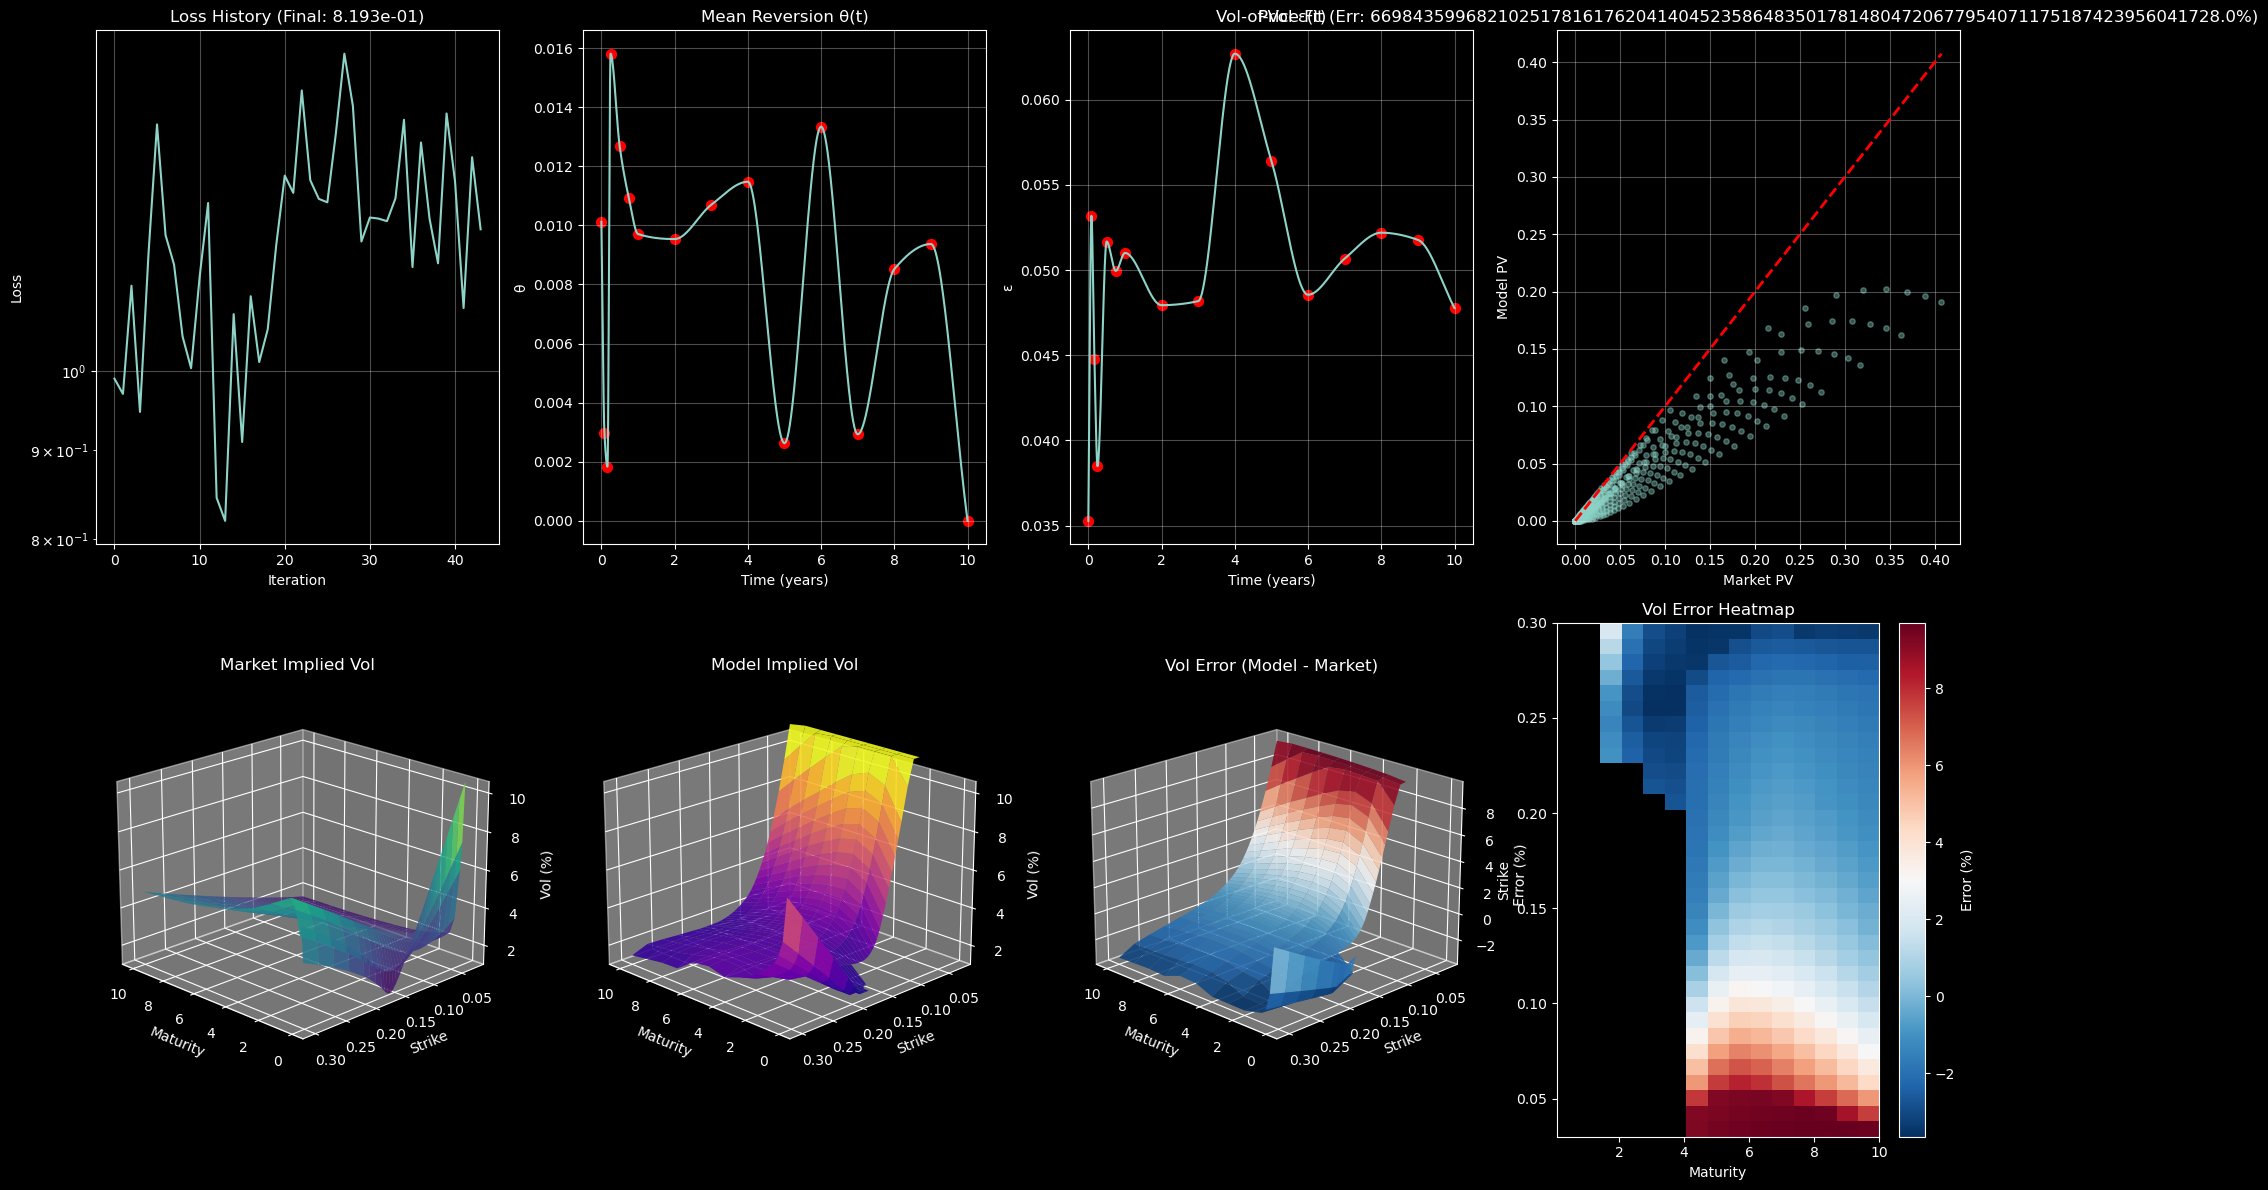


Market Vol: 0.97-10.58% (mean: 3.29%)
Model Vol:  1.16-11.36% (mean: 3.88%)
Vol RMSE: 3.59% | MAE: 2.64%


In [ ]:
# Visualization
import pickle
with open(Path('../../../data/multi_theta_final.pkl'), 'rb') as f: ckpt = pickle.load(f)

theta_t = evaluate_timeline(timeline, ckpt['time_to_maturities'], ckpt['theta_values'])
eps_t = ckpt['epsilon'] * torch.ones_like(timeline)  # Constant epsilon

with torch.no_grad():
    model = create_key_rate_model(timeline, 500, key_ifwd_curve, ois_ifwd_curve, r0, r0, 
                                 ckpt['v0'], ckpt['kappa'], theta_t, eps_t, 
                                 torch.tensor(0.0), ckpt['lam'], torch.tensor(0.0), ckpt['gamma'], ckpt['xi'])
    price_key_caplet_surface(model, vol_key_rate, fwd_key_rate)

comparison = vol_key_rate[['time_to_maturity','strike','implied_normal_vol','pv','pv_model_key']].copy()

# Validate market data
print(f"Market Vol Stats: min={comparison['implied_normal_vol'].min():.4f}, max={comparison['implied_normal_vol'].max():.4f}, mean={comparison['implied_normal_vol'].mean():.4f}")
print(f"Market PV Stats: min={comparison['pv'].min():.6f}, max={comparison['pv'].max():.6f}")
print(f"Model PV Stats: min={comparison['pv_model_key'].min():.6f}, max={comparison['pv_model_key'].max():.6f}")

mats, strikes = sorted(comparison['time_to_maturity'].unique()), sorted(comparison['strike'].unique())
T_grid, K_grid = np.meshgrid(mats, strikes)

from scipy.optimize import brentq
from scipy.stats import norm

def bachelier_price(F, K, sigma, tau):
    d = (F - K) / (sigma * np.sqrt(tau)) if sigma > 1e-10 else 0
    return (F - K) * norm.cdf(d) + sigma * np.sqrt(tau) * norm.pdf(d)

def implied_vol_from_price(F, K, price, tau):
    if price <= max(F - K, 0) + 1e-10: return np.nan
    try:
        return brentq(lambda sig: bachelier_price(F, K, sig, tau) - price, 1e-6, 2.0, xtol=1e-6)
    except: return np.nan

fwd_dict = {t: fwd_key_rate[fwd_key_rate['time_to_maturity']==t]['forward_rate'].values[0] for t in fwd_key_rate['time_to_maturity'].unique()}
comparison['forward'] = comparison['time_to_maturity'].map(fwd_dict)
comparison['model_implied_vol'] = comparison.apply(lambda r: implied_vol_from_price(r['forward'], r['strike'], r['pv_model_key'], r['time_to_maturity']), axis=1)

# Clip outliers in model vols (keep 5-95 percentile range)
valid_mask = ~comparison['model_implied_vol'].isna()
if valid_mask.sum() > 0:
    p5, p95 = comparison.loc[valid_mask, 'model_implied_vol'].quantile([0.05, 0.95])
    comparison.loc[valid_mask & (comparison['model_implied_vol'] > p95), 'model_implied_vol'] = p95
    comparison.loc[valid_mask & (comparison['model_implied_vol'] < p5), 'model_implied_vol'] = p5
    print(f"Model vol outliers clipped to [{p5*100:.2f}%, {p95*100:.2f}%]")

market_vol_grid = np.array([[comparison[(comparison['time_to_maturity']==t)&(comparison['strike']==k)]['implied_normal_vol'].values[0] 
                            if len(comparison[(comparison['time_to_maturity']==t)&(comparison['strike']==k)])>0 else np.nan for t in mats] for k in strikes])
model_vol_grid = np.array([[comparison[(comparison['time_to_maturity']==t)&(comparison['strike']==k)]['model_implied_vol'].values[0] 
                           if len(comparison[(comparison['time_to_maturity']==t)&(comparison['strike']==k)])>0 else np.nan for t in mats] for k in strikes])
error_grid = model_vol_grid - market_vol_grid

fig = plt.figure(figsize=(20,12))

# Row 1: Calibration diagnostics
ax1 = fig.add_subplot(241); ax1.plot(ckpt['history']); ax1.set_yscale('log'); ax1.set_xlabel('Iteration'); ax1.set_ylabel('Loss'); ax1.set_title(f"Loss History (Final: {ckpt['loss']:.3e})"); ax1.grid(alpha=0.3)
ax2 = fig.add_subplot(242); ax2.plot(timeline, theta_t); ax2.scatter(ckpt['time_to_maturities'], ckpt['theta_values'], c='r', s=50); ax2.set_xlabel('Time (years)'); ax2.set_ylabel('θ'); ax2.set_title('Mean Reversion θ(t)'); ax2.grid(alpha=0.3)
ax3 = fig.add_subplot(243); ax3.axhline(y=ckpt['epsilon'], color='g', linewidth=3, label=f"ε = {ckpt['epsilon']:.4f}"); ax3.set_xlabel('Time (years)'); ax3.set_ylabel('ε'); ax3.set_title('Vol-of-Vol ε (constant)'); ax3.legend(); ax3.grid(alpha=0.3); ax3.set_xlim(0, 10)
ax4 = fig.add_subplot(244); ax4.scatter(comparison['pv'], comparison['pv_model_key'], alpha=0.4, s=15); ax4.plot([0, comparison['pv'].max()], [0, comparison['pv'].max()], 'r--', lw=2); ax4.set_xlabel('Market PV'); ax4.set_ylabel('Model PV'); ax4.set_title(f"Price Fit (Err: {(abs(comparison['pv_model_key']-comparison['pv'])/comparison['pv']).mean()*100:.1f}%)"); ax4.grid(alpha=0.3)

# Row 2: Volatility surfaces (same z-scale for comparison)
vmin, vmax = np.nanmin([market_vol_grid.min(), model_vol_grid.min()])*100, np.nanmax([market_vol_grid.max(), model_vol_grid.max()])*100
ax5 = fig.add_subplot(245, projection='3d'); surf1 = ax5.plot_surface(T_grid, K_grid, market_vol_grid*100, cmap='viridis', vmin=vmin, vmax=vmax, alpha=0.9); ax5.set_xlabel('Maturity'); ax5.set_ylabel('Strike'); ax5.set_zlabel('Vol (%)'); ax5.set_title('Market Implied Vol'); ax5.view_init(20,135); ax5.set_zlim(vmin, vmax)
ax6 = fig.add_subplot(246, projection='3d'); surf2 = ax6.plot_surface(T_grid, K_grid, model_vol_grid*100, cmap='plasma', vmin=vmin, vmax=vmax, alpha=0.9); ax6.set_xlabel('Maturity'); ax6.set_ylabel('Strike'); ax6.set_zlabel('Vol (%)'); ax6.set_title('Model Implied Vol'); ax6.view_init(20,135); ax6.set_zlim(vmin, vmax)
ax7 = fig.add_subplot(247, projection='3d'); surf3 = ax7.plot_surface(T_grid, K_grid, error_grid*100, cmap='RdBu_r', alpha=0.9); ax7.set_xlabel('Maturity'); ax7.set_ylabel('Strike'); ax7.set_zlabel('Error (%)'); ax7.set_title('Vol Error (Model - Market)'); ax7.view_init(20,135)
ax8 = fig.add_subplot(248); im = ax8.imshow(error_grid*100, cmap='RdBu_r', aspect='auto', origin='lower', extent=[min(mats), max(mats), min(strikes), max(strikes)]); ax8.set_xlabel('Maturity'); ax8.set_ylabel('Strike'); ax8.set_title('Vol Error Heatmap'); plt.colorbar(im, ax=ax8, label='Error (%)')

plt.tight_layout(); plt.show()

valid_model = model_vol_grid[~np.isnan(model_vol_grid)]
vol_errors = comparison[~comparison['model_implied_vol'].isna()]['model_implied_vol'] - comparison[~comparison['model_implied_vol'].isna()]['implied_normal_vol']
print(f"\nMarket Vol: {market_vol_grid.min()*100:.2f}-{market_vol_grid.max()*100:.2f}% (mean: {np.nanmean(market_vol_grid)*100:.2f}%)")
print(f"Model Vol:  {valid_model.min()*100:.2f}-{valid_model.max()*100:.2f}% (mean: {np.nanmean(valid_model)*100:.2f}%)")
print(f"Vol RMSE: {np.sqrt(np.mean(vol_errors**2))*100:.2f}% | MAE: {np.mean(np.abs(vol_errors))*100:.2f}%")